In [14]:
import numpy as np
import pandas as pd
import scanpy as sc
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sknetwork.clustering import Leiden

seed = 123

## Read the pre-processed dataset (see Task 1)

In [15]:
data_dir = '../data/frangieh'
adata = sc.read_h5ad(f"{data_dir}/dataset_hv_tim.h5ad")

## Define functions for clustering (including visualizatino with UMAP)

In [16]:
def aggregate_perturbations(adata):
    # Combine all cells with the same perturbation by mean expression value per gene
    data = adata.copy()
    treatment = data.obs.perturbation_2.values[0]
    data = sc.get.aggregate(data, by='perturbation', func='mean')
    data.X = data.layers['mean'].copy()
    data.obs['perturbation_2'] = treatment
    return data

def cl_leiden(adata, res=1, plot=False, title=None):
    data = adata.copy()
    adjacency = data.obsp['connectivities'].copy()
    leiden = Leiden(resolution=res, random_state=seed).fit(adjacency)
    data.obs['leiden'] = leiden.labels_.astype(str)
    if plot:
        sc.pl.umap(data, color='leiden', title=title)
    return data

def cl_kmeans(adata, k=8, plot=False, title=None):
    data = adata.copy()
    X_pca = data.obsm['X_pca']
    kmeans = KMeans(n_clusters=k, random_state=seed).fit(X_pca)
    data.obs['kmeans'] = kmeans.labels_.astype(str)
    if plot:
        sc.pl.umap(data, color='kmeans', title=title)
    return data, kmeans

### Aggregate rows by perturbation and take the mean gene expression values split by treatment condition. Then perform dimensionality reduction on the individual datasets.

In [17]:
adata_ctl = adata[adata.obs['perturbation_2'].eq('Control')]
adata_ctl = aggregate_perturbations(adata_ctl)

adata_IFN = adata[adata.obs['perturbation_2'].eq('IFNγ')]
adata_IFN = aggregate_perturbations(adata_IFN)

adata_co = adata[adata.obs['perturbation_2'].eq('Co-culture')]
adata_co = aggregate_perturbations(adata_co)

In [18]:
def dim_reduction(adata):
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

In [19]:
dim_reduction(adata_ctl)
dim_reduction(adata_IFN)
dim_reduction(adata_co)

# KMeans

## Find optimal number of clusters using silhouette score

In [20]:
for treatment_df in [adata_ctl, adata_IFN, adata_co]:
    print(f'-----------------------------------\n'
          f'{treatment_df.obs['perturbation_2'].values [0]}\n')
    data = treatment_df.copy()
    X_pca = data.obsm['X_pca']
    for k in range(2,16):
        kmeans = KMeans(n_clusters=k, random_state=seed).fit(X_pca)
        labels = kmeans.labels_.astype(str)
        silhouette_avg = silhouette_score(X_pca, labels, random_state=seed)
        print(f'k = {k}:\t avg silhouette score = {silhouette_avg:.3f}')

-----------------------------------
Control

k = 2:	 avg silhouette score = 0.419
k = 3:	 avg silhouette score = 0.515
k = 4:	 avg silhouette score = 0.268
k = 5:	 avg silhouette score = 0.445
k = 6:	 avg silhouette score = 0.091
k = 7:	 avg silhouette score = 0.122
k = 8:	 avg silhouette score = 0.090
k = 9:	 avg silhouette score = 0.092
k = 10:	 avg silhouette score = 0.069
k = 11:	 avg silhouette score = 0.076
k = 12:	 avg silhouette score = 0.054
k = 13:	 avg silhouette score = 0.055
k = 14:	 avg silhouette score = 0.054
k = 15:	 avg silhouette score = 0.054
-----------------------------------
IFNγ

k = 2:	 avg silhouette score = 0.761
k = 3:	 avg silhouette score = 0.475
k = 4:	 avg silhouette score = 0.461
k = 5:	 avg silhouette score = 0.089
k = 6:	 avg silhouette score = 0.109
k = 7:	 avg silhouette score = 0.055
k = 8:	 avg silhouette score = 0.382
k = 9:	 avg silhouette score = 0.384
k = 10:	 avg silhouette score = 0.380
k = 11:	 avg silhouette score = 0.382
k = 12:	 avg silh

## Find optimal number of clusters using elbow method

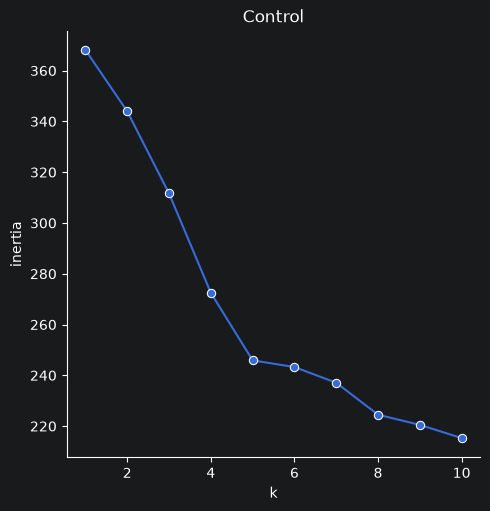

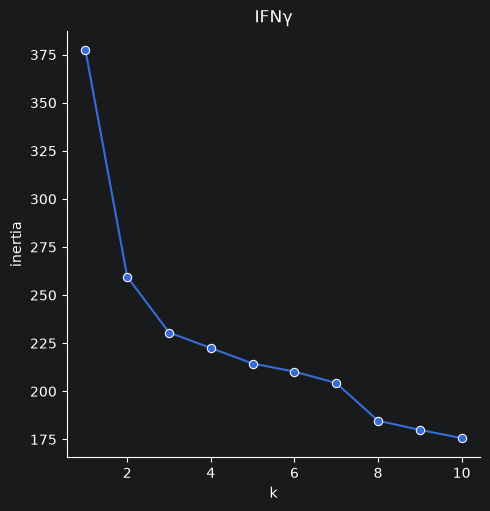

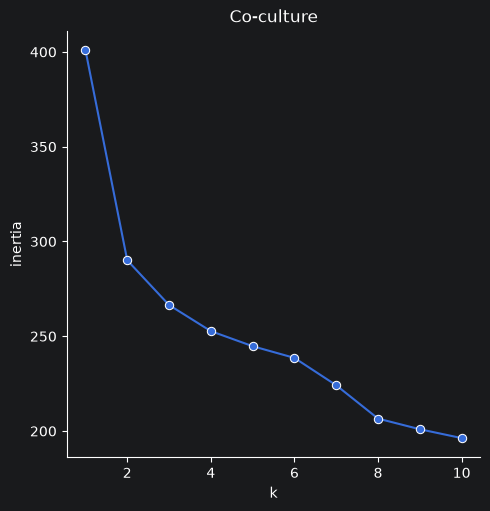

In [21]:
for treatment_df in [adata_ctl, adata_IFN, adata_co]:
    inertias = []
    for k in range(1,11):
        _, kmeans = cl_kmeans(adata=treatment_df, k=k)
        inertias.append(kmeans.inertia_)

    inertias = {
        'k':range(1,11),
        'inertia':inertias,
    }

    sns.relplot(inertias, x='k', y='inertia', kind='line', marker='o')
    plt.title(treatment_df.obs.perturbation_2.values[0])

Resulting optimal k is 3 for control using both silhouette and elbow methods. For IFN treated and co-culture cells, best k is 2 according to silhouette and 3 according to ellbow methods. When using k=2, many biological effects can't be observed as only the strong separation between IFN pathway genes and all other genes is captured. For now, k=3 is selected for all conditions.

## Clustering results

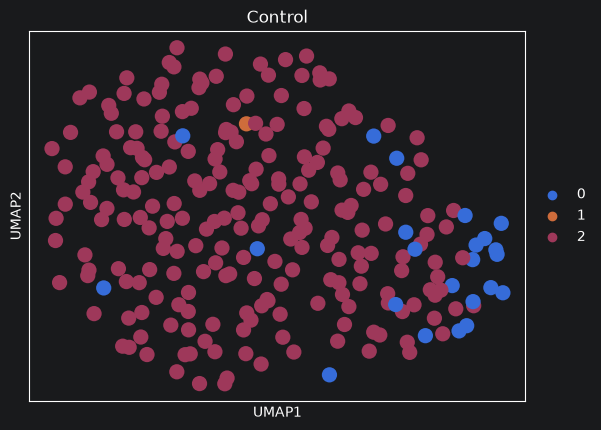

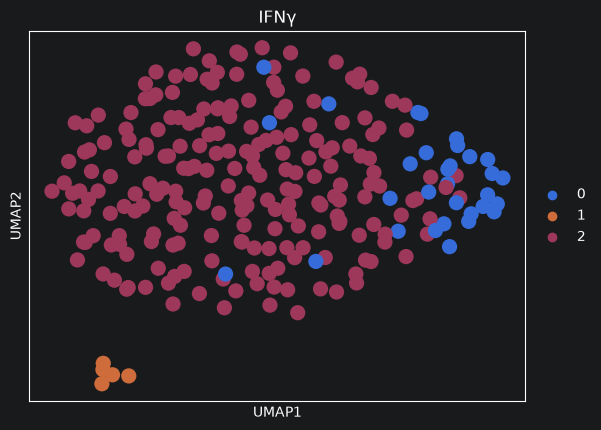

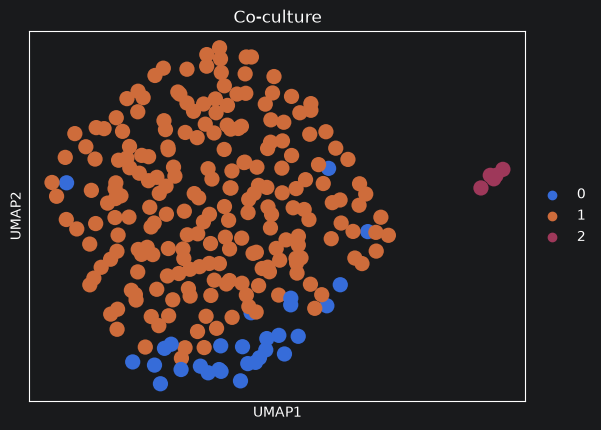

In [22]:
for condition_data, k in [[adata_ctl,3], [adata_IFN,3], [adata_co,3]]:
    data, _kmeans = cl_kmeans(
        adata=condition_data,
        k=k,
        plot=True,
        title=condition_data.obs.perturbation_2.values[0])
    condition_data.obs['kmeans'] = data.obs['kmeans']

## Evaluate, which perturbations cluster together by treatment condition

In [23]:
# kmeans
for treatment_df in [adata_ctl, adata_IFN, adata_co]:
    print('------------------------------------------------')
    print (treatment_df.obs.perturbation_2.values[0])
    for cluster in treatment_df.obs.kmeans.cat.categories:
        print(f'\n\nk-means #{cluster}')
        data = treatment_df[treatment_df.obs.kmeans == cluster].obs
        print(data)

------------------------------------------------
Control


k-means #0
         perturbation  n_obs_aggregated perturbation_2 kmeans
AHCY             AHCY                34        Control      0
CCT3             CCT3                51        Control      0
CCT6A           CCT6A                14        Control      0
CDK6             CDK6               109        Control      0
CTPS1           CTPS1               114        Control      0
EEF1G           EEF1G                46        Control      0
EIF4A1         EIF4A1                48        Control      0
FARSA           FARSA                24        Control      0
GPI               GPI                48        Control      0
ILF2             ILF2                53        Control      0
MYC               MYC                40        Control      0
PAICS           PAICS                65        Control      0
PPA1             PPA1                31        Control      0
PRELID3B     PRELID3B                33        Control      0


# Leiden

## Find optimal leiden resolution using silhouette score

In [24]:
for treatment_df in [adata_ctl, adata_IFN, adata_co]:
    print(f'-----------------------------------\n'
          f'{treatment_df.obs['perturbation_2'].values [0]}\n')
    data = treatment_df.copy()
    adjacency = data.obsp['connectivities'].copy()
    for res in np.arange(0.3, 2, 0.1):
        leiden = Leiden(resolution=res, random_state=seed).fit(adjacency)
        labels = leiden.labels_.astype(str)
        silhouette_avg = silhouette_score(X_pca, labels, random_state=seed)
        print(f'res = {res:.1f}:\t avg silhouette score = {silhouette_avg:.3f}')

-----------------------------------
Control

res = 0.3:	 avg silhouette score = 0.107
res = 0.4:	 avg silhouette score = 0.032
res = 0.5:	 avg silhouette score = -0.041
res = 0.6:	 avg silhouette score = -0.042
res = 0.7:	 avg silhouette score = -0.113
res = 0.8:	 avg silhouette score = -0.179
res = 0.9:	 avg silhouette score = -0.164
res = 1.0:	 avg silhouette score = -0.196
res = 1.1:	 avg silhouette score = -0.206
res = 1.2:	 avg silhouette score = -0.220
res = 1.3:	 avg silhouette score = -0.207
res = 1.4:	 avg silhouette score = -0.195
res = 1.5:	 avg silhouette score = -0.254
res = 1.6:	 avg silhouette score = -0.270
res = 1.7:	 avg silhouette score = -0.304
res = 1.8:	 avg silhouette score = -0.265
res = 1.9:	 avg silhouette score = -0.274
-----------------------------------
IFNγ

res = 0.3:	 avg silhouette score = 0.281
res = 0.4:	 avg silhouette score = 0.025
res = 0.5:	 avg silhouette score = -0.014
res = 0.6:	 avg silhouette score = -0.042
res = 0.7:	 avg silhouette score = 

The highest score is achieved with a resolution of 0.3 for control, 0.3 for IFN-treated cells and 0.3 for co-cultured cells.


## Clustering results

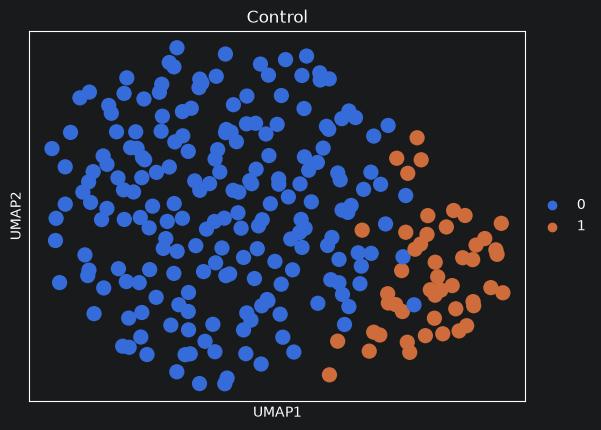

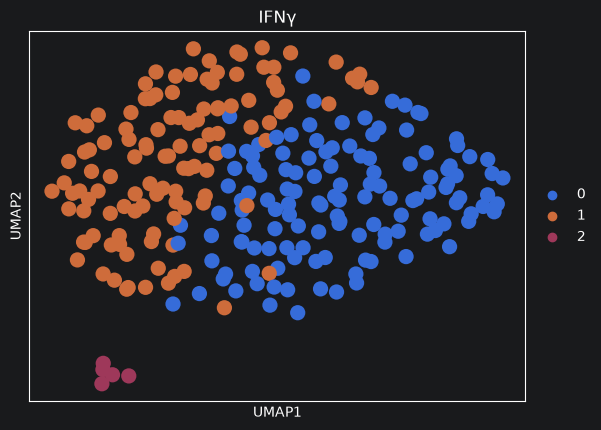

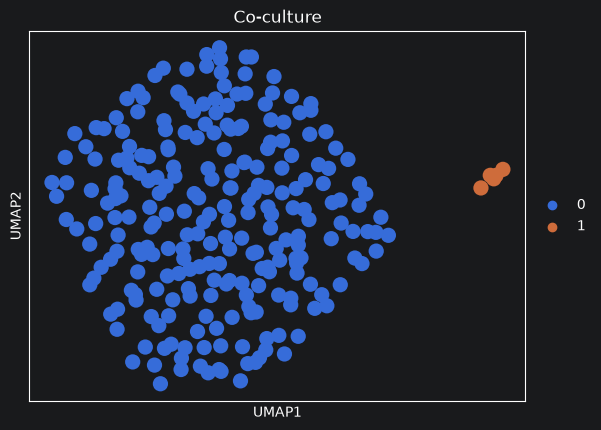

In [25]:
for condition_data, res in [[adata_ctl,0.3], [adata_IFN,0.3], [adata_co,0.3]]:
    data = cl_leiden(
        adata=condition_data,
        res=res,
        plot=True,
        title=condition_data.obs.perturbation_2.values[0],
    )
    condition_data.obs['leiden'] = data.obs['leiden'].astype('category')

In [26]:
# Leiden
for treatment_df in [adata_ctl, adata_IFN, adata_co]:
    print('------------------------------------------------')
    print (treatment_df.obs.perturbation_2.values[0])
    for cluster in treatment_df.obs.leiden.cat.categories:
        print(f'\n\nLeiden #{cluster}')
        data = treatment_df[treatment_df.obs.leiden == cluster].obs
        print(data)

------------------------------------------------
Control


Leiden #0
       perturbation  n_obs_aggregated perturbation_2 kmeans leiden
ACTA2         ACTA2               407        Control      2      0
AEBP1         AEBP1               389        Control      2      0
AHNAK         AHNAK               320        Control      2      0
APOC2         APOC2               316        Control      2      0
APOE           APOE               317        Control      2      0
...             ...               ...            ...    ...    ...
VAT1           VAT1               113        Control      2      0
VDAC2         VDAC2               134        Control      2      0
WBP2           WBP2               123        Control      2      0
WNT7A         WNT7A               149        Control      2      0
XAGE1A       XAGE1A               100        Control      2      0

[201 rows x 5 columns]


Leiden #1
         perturbation  n_obs_aggregated perturbation_2 kmeans leiden
A2M               A2M 

**One noticeable observation:**<br>
JAK/STAT pathway genes (JAK1/2, STAT1, IFNGR1/2) cluster together in IFN and co-culture conditions -> JAK/STAT pathway is compromised which alters gene expression in an environment in which IFN is present.